In [50]:
# import libraries for the project

import warnings
warnings.filterwarnings('ignore')  # Suppress warnings for cleaner output


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [51]:
# load the dataset

df = pd.read_csv('store_customers.csv')
#remove any rows with missing values to ensure the clustering algorithm works effectively without errors due to NaN values.
df = df.dropna()
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,M,39.0,59.9,58.0
1,1001,M,34.0,48.4,37.0
2,1002,F,40.0,70.5,26.0
3,1003,F,47.0,81.1,30.0
4,1004,F,33.0,42.1,58.0


In [52]:
# selection of features for clustering(income and spending score)

x = df[['Annual Income (k$)', 'Spending Score (1-100)']]

In [53]:
# Scaling the data to ensure that all features contribute equally to the clustering process as KMeans is sensitive to the scale of the data.
#example: income = 100, score = 10 - without scaling, the income feature would dominate the clustering process,
# leading to clusters that are primarily based on income rather than a balanced consideration of both features.

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

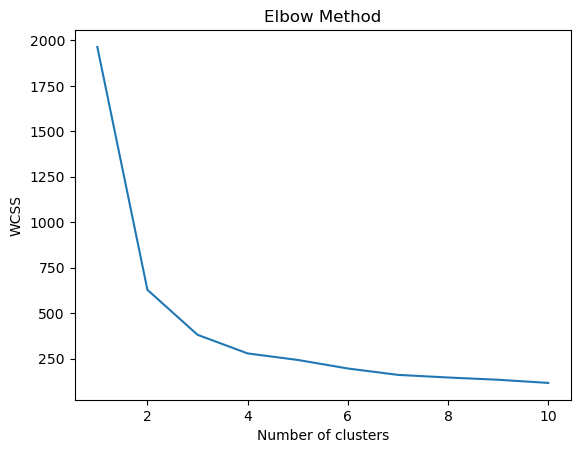

In [54]:
# Determine the optimal number of clusters using the Elbow Method
#wcss - how compact the clusters are, lower wcss means more compact clusters. 
# The elbow point is where the rate of decrease sharply changes, 
# indicating that adding more clusters does not significantly improve the compactness of the clusters.

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(x_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [55]:
# Silhouette Score Analysis to determine best cluster number,
#scores range from -1 to 1, where a higher score indicates better-defined clusters.

for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    labels = kmeans.fit_predict(x_scaled)
    score = silhouette_score(x_scaled, labels)
    print(f'Clusters: {i}, Score: {score}')

Clusters: 2, Score: 0.5835726782240923
Clusters: 3, Score: 0.47449519099140786
Clusters: 4, Score: 0.39604378225837017
Clusters: 5, Score: 0.35374964532033915
Clusters: 6, Score: 0.3707082527470912
Clusters: 7, Score: 0.3732245755293607
Clusters: 8, Score: 0.3693707634532734
Clusters: 9, Score: 0.363270356823448
Clusters: 10, Score: 0.3537239290234216


In [56]:
# Train the KMeans model with the optimal number of clusters (let's say 2 based on the previous analysis)

kmeans = KMeans(n_clusters=2, random_state=42)
df['Cluster'] = kmeans.fit_predict(x_scaled)

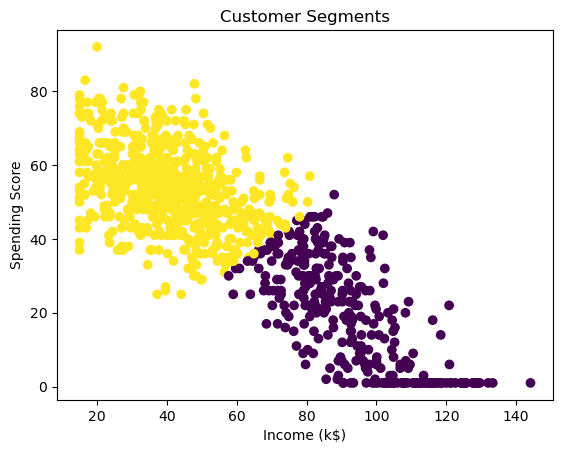

In [57]:
# Visualize the clusters to understand the segmentation of customers based on their annual income and spending score.

plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c=df['Cluster'], cmap='viridis')
plt.xlabel('Income (k$)')
plt.ylabel('Spending Score')
plt.title('Customer Segments')
plt.show()

In [58]:
# interpretation of the clusters can be done by analyzing the characteristics of each cluster,
# such as average income and spending score, to identify distinct customer segments for targeted marketing strategies.

df.groupby('Cluster').mean()

TypeError: agg function failed [how->mean,dtype->object]